In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_moons

# Q1 Two moons with an invertible neural network


### RealNVP Implementation

In [36]:
class CouplingLayer(nn.Module):
    def __init__(self, input_size, hidden_size, mask):
        """
        input size: data dim 
        hidden size: networks width (could be larger than data dim)
        maks: 1 - skip connection for 1st half dim
              0 - affine transformation for 2nd half dim
        """
        super().__init__()
        self.register_buffer("mask", mask)

        # nested network
        self.nested_net = nn.Sequential( 
            nn.Linear(input_size, hidden_size), # 1st hidden layer
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), # 2nd hidden layer
            nn.ReLU(),
           nn.Linear(hidden_size, 2 * input_size) # linear output layer, output: translation + scale
        )

    def forward(self, x):
        m = self.mask
        x_id = x * m 
        h = self.nested_net(x_id)
        t, s = torch.chunk(h, 2, dim=-1) # translation, scale
        s = torch.tanh(s)
        scale = torch.exp(s)

        y = x_id + (1-m) * (x * scale + t)
        logdet = ((1-m) * s).sum(-1) # log det Jacobian
        return y, logdet
    
    def inverse(self, y):
        m = self.mask
        y_id = y * m
        h = self.nested_net(y_id)
        t, s = torch.chunk(h, 2, dim=-1)
        s = torch.tanh(s)
        scale = torch.exp(s)

        x = y_id + (1-m) * ((y-t)/scale)
        logdet = -((1-m) * s).sum(dim=-1) # log det Jacobian
        return x, logdet



def random_O(dim=2):
    """Generates random rotation (orthogonal matrix) using qr"""
    W = torch.randn(dim, dim)
    q, r= torch.linalg.qr(W)
    return q


class realNVP(nn.Module):
    def __init__(self, input_size=2, hidden_size=16, blocks=4):
        super().__init__()

        # masks for alternating skip (1,0) & affine transf (0,1)
        masks = []
        for i in range(blocks):
            if i % 2 == 0: 
                masks.append(torch.tensor([1., 0.]))
            else:
                masks.append(torch.tensor([0., 1.]))
            
        # coupling blocks
        self.blocks = blocks
        self.couplings = nn.ModuleList([
            CouplingLayer(input_size, hidden_size, m) for m in masks
        ])

        # random rotation 
        self.rotations = nn.ModuleList()
        for b in range(blocks-1):
            R = nn.Linear(input_size, input_size, bias=False)
            with torch.no_grad():
                R.weight.copy_(random_O(input_size))
            for p in R.parameters():
                p.requires_grad = False
            self.rotations.append(R)
        # last layer w/o rotation 
        R = nn.Linear(input_size, input_size, bias=False)
        with torch.no_grad():
            R.weight.data = torch.eye(input_size)
        R.weight.requires_grad_(False)
        self.rotations.append(R)


    def forward(self, x):
        logdet_total = torch.zeros(x.size(0), device=x.device)
        y = x
        for i in range(self.blocks): # blocks
            y, logdet = self.couplings[i](y) # coupling layer
            logdet_total += logdet
            y = self.rotations[i](y) # random rotation
        return y, logdet_total
    
    def inverse(self, y):
        logdet_total = torch.zeros(y.size(0), device=y.device)
        x = y
        for i in reversed(range(self.blocks)):
            R = self.rotations[i].weight
            x = torch.matmul(x, R.t()) # x * R^-1
            x, logdet = self.couplings[i].inverse(x)
            logdet_total += logdet
        return x, logdet_total
    
    def sample(self, num_samples, device=None):
        if device is None:
            device = next(self.parameters()).device
        dim = self.couplings[0].mask.numel() 
        z = torch.randn(num_samples, dim, device=device) # draw 2 numbers from gaussian distr
        x, _ = self.inverse(z) # apply decoder
        return x

    


### Training

In [22]:
def nll_loss(z, log_det):
    D = z.size(1)
    log_pz = -0.5 * (z ** 2).sum(dim=1) - 0.5 * D * np.log(2 * np.pi)
    log_px = log_pz + log_det
    return -log_px.mean()

def train_inn(x, hidden_size=32, blocks=4, 
              n_train=1000, batch_size=128, lr=1e-3, epochs=10):
    
    # datasets
    x = torch.tensor(x, dtype=torch.float32)
    input_size = x.shape[1]
    loader = DataLoader(TensorDataset(x), batch_size=batch_size, shuffle=True)

    model = realNVP(input_size, hidden_size, blocks)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for ep in range(epochs):
        for (batch_x, ) in loader:
            z, log_det = model(batch_x)
            loss = nll_loss(z, log_det)

            optimizer.zero_grad()
            loss.backward() # ???
            optimizer.step()

        if (ep + 1) % 10 == 0:
            print(f"Epoch {ep+1}/{epochs}, loss={loss.item():.3f}")

    return model



In [23]:
# two moons dataset
n_train = 1000
noise = 0.1
x, _ = make_moons(n_samples = n_train, noise=noise)

In [37]:
batch_size=128
lr=5e-3
epochs=300

model = train_inn(x, batch_size=batch_size, lr=lr, epochs=epochs)

Epoch 10/300, loss=1.485
Epoch 20/300, loss=1.357
Epoch 30/300, loss=1.423
Epoch 40/300, loss=1.320
Epoch 50/300, loss=1.344
Epoch 60/300, loss=1.372
Epoch 70/300, loss=1.065
Epoch 80/300, loss=1.175
Epoch 90/300, loss=1.152
Epoch 100/300, loss=1.207
Epoch 110/300, loss=1.017
Epoch 120/300, loss=1.216
Epoch 130/300, loss=1.123
Epoch 140/300, loss=1.143
Epoch 150/300, loss=0.980
Epoch 160/300, loss=1.037
Epoch 170/300, loss=1.156
Epoch 180/300, loss=0.990
Epoch 190/300, loss=1.109
Epoch 200/300, loss=1.102
Epoch 210/300, loss=0.946
Epoch 220/300, loss=1.052
Epoch 230/300, loss=1.070
Epoch 240/300, loss=1.287
Epoch 250/300, loss=1.065
Epoch 260/300, loss=1.025
Epoch 270/300, loss=0.957
Epoch 280/300, loss=1.147
Epoch 290/300, loss=1.041
Epoch 300/300, loss=1.198


Text(0.5, 1.0, 'Code distribution (should look ~ N(0,I))')

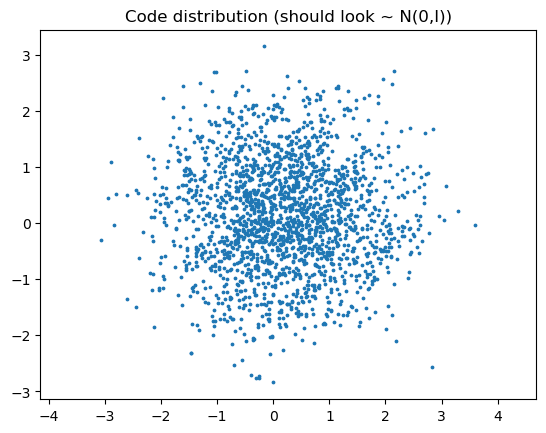

In [38]:
x_test, _ = make_moons(n_samples=2000, noise=0.1)
x_test = torch.tensor(x_test, dtype=torch.float32)
z_test, _ = model(x_test)

z_np = z_test.detach().numpy()
plt.figure()
plt.scatter(z_np[:,0], z_np[:,1], s=3)
plt.axis('equal')
plt.title("Code distribution (should look ~ N(0,I))")


Text(0.5, 1.0, 'Generated')

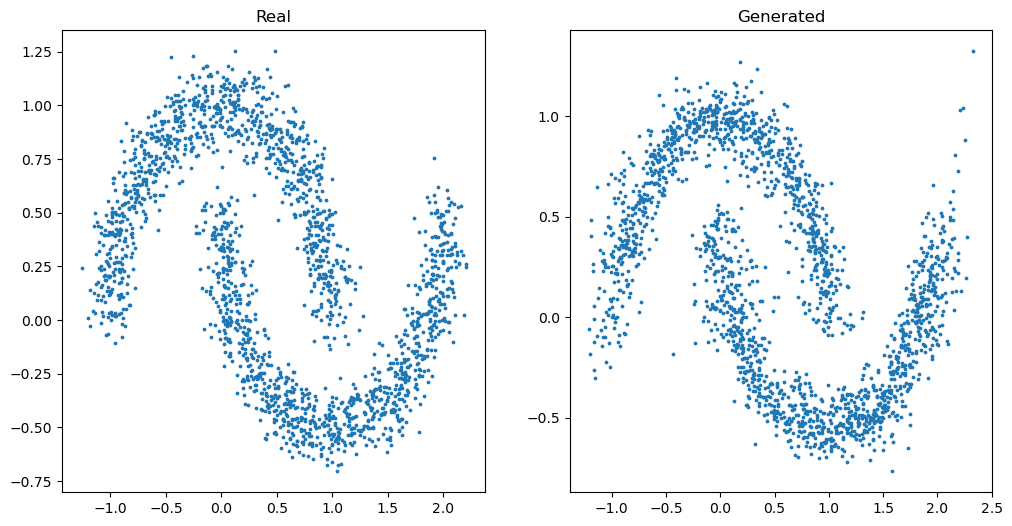

In [41]:
with torch.no_grad():
    x_gen = model.sample(2000).numpy()
x_real, _ = make_moons(n_samples=2000, noise=0.1)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.scatter(x_real[:,0], x_real[:,1], s=3); plt.title("Real")
plt.subplot(1,2,2); plt.scatter(x_gen[:,0], x_gen[:,1], s=3); plt.title("Generated")


### Hexagon GMM data

In [76]:
def make_hexagon_gmm(n_samples=2000, R=1.0, sigma=0.1):
    centers = []
    for k in range(6):
        theta = 2 * np.pi * k / 6
        centers.append((R * np.cos(theta), R * np.sin(theta)))
    centers = np.array(centers)

    comp = np.random.randint(0, 6, size=n_samples)
    means = centers[comp]
    x = means + sigma * np.random.randn(n_samples, 2)
    return x


Epoch 10/300, loss=1.269
Epoch 20/300, loss=1.041
Epoch 30/300, loss=0.778
Epoch 40/300, loss=0.968
Epoch 50/300, loss=0.665
Epoch 60/300, loss=0.602
Epoch 70/300, loss=0.841
Epoch 80/300, loss=0.655
Epoch 90/300, loss=0.538
Epoch 100/300, loss=0.566
Epoch 110/300, loss=0.804
Epoch 120/300, loss=0.694
Epoch 130/300, loss=0.546
Epoch 140/300, loss=0.592
Epoch 150/300, loss=0.466
Epoch 160/300, loss=0.501
Epoch 170/300, loss=0.962
Epoch 180/300, loss=0.263
Epoch 190/300, loss=0.509
Epoch 200/300, loss=0.375
Epoch 210/300, loss=0.514
Epoch 220/300, loss=0.212
Epoch 230/300, loss=0.725
Epoch 240/300, loss=0.319
Epoch 250/300, loss=0.368
Epoch 260/300, loss=0.385
Epoch 270/300, loss=0.396
Epoch 280/300, loss=0.732
Epoch 290/300, loss=0.318
Epoch 300/300, loss=0.141


Text(0.5, 1.0, 'Generated')

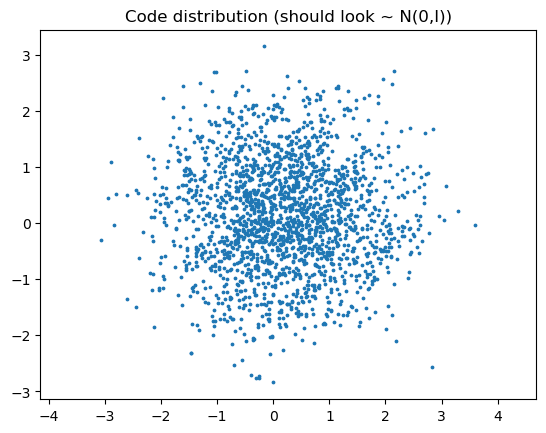

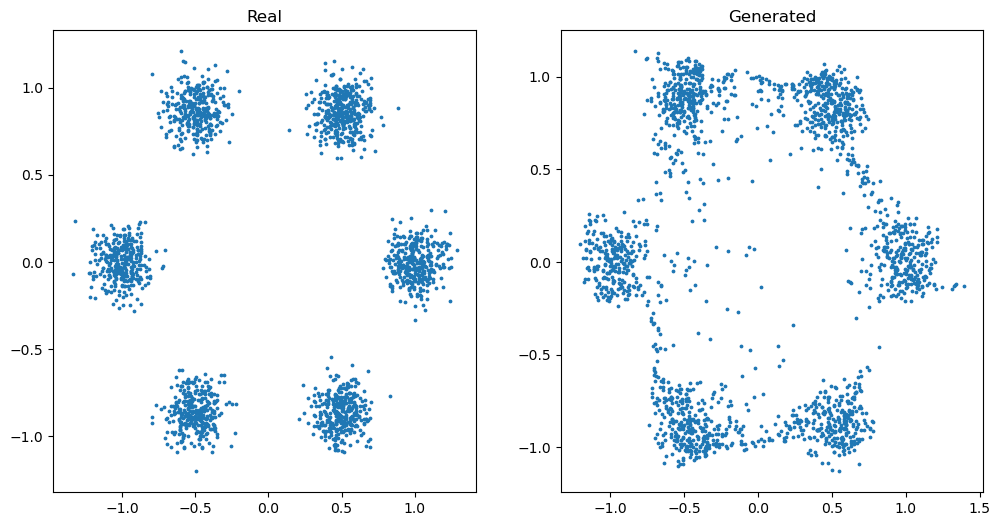

In [78]:
hex = make_hexagon_gmm()

hidden_size=64
batch_size=64
lr=1e-4
epochs=300
blocks=8

hex_model = train_inn(hex, hidden_size=hidden_size, batch_size=batch_size, lr=lr, epochs=epochs, blocks=blocks)

hex_test = make_hexagon_gmm()
hex_test = torch.tensor(hex_test, dtype=torch.float32)
z_hex, _ = hex_model(hex_test)

z_np = z_test.detach().numpy()
plt.figure()
plt.scatter(z_np[:,0], z_np[:,1], s=3)
plt.axis('equal')
plt.title("Code distribution (should look ~ N(0,I))")

with torch.no_grad():
    hex_gen = hex_model.sample(2000).numpy()
hex_real = make_hexagon_gmm(n_samples=2000)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.scatter(hex_real[:,0], hex_real[:,1], s=3); plt.title("Real")
plt.subplot(1,2,2); plt.scatter(hex_gen[:,0], hex_gen[:,1], s=3); plt.title("Generated")


--- Running Two Moons Experiment ---
Starting training...
Epoch 50/200 | Loss: 0.3589
Epoch 100/200 | Loss: 0.3426
Epoch 150/200 | Loss: 0.3303
Epoch 200/200 | Loss: 0.3533


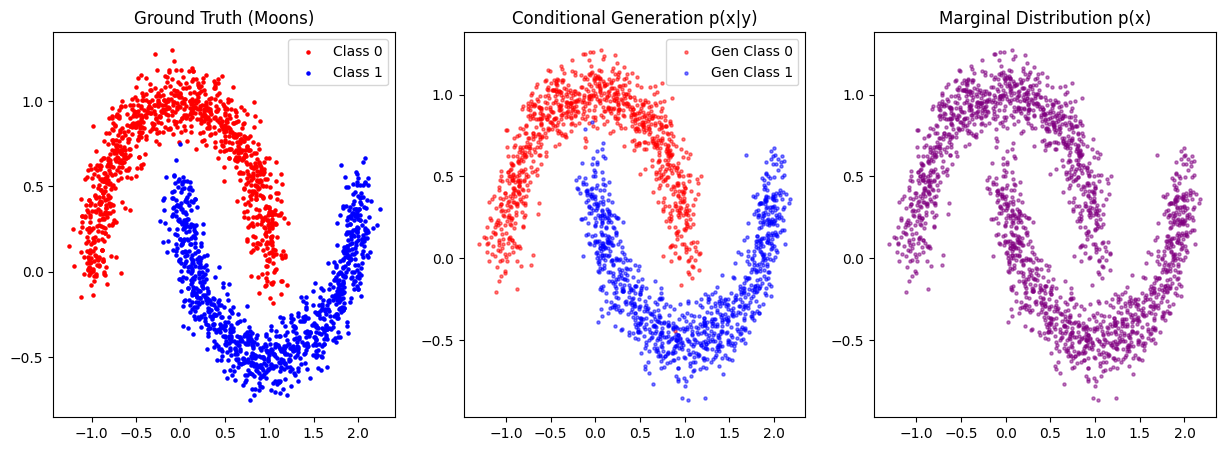


--- Running Hexagon GMM Experiment ---
Starting training...
Epoch 50/300 | Loss: -0.1991
Epoch 100/300 | Loss: -0.3523
Epoch 150/300 | Loss: -0.3118
Epoch 200/300 | Loss: -0.4139
Epoch 250/300 | Loss: -0.4426
Epoch 300/300 | Loss: -0.4850


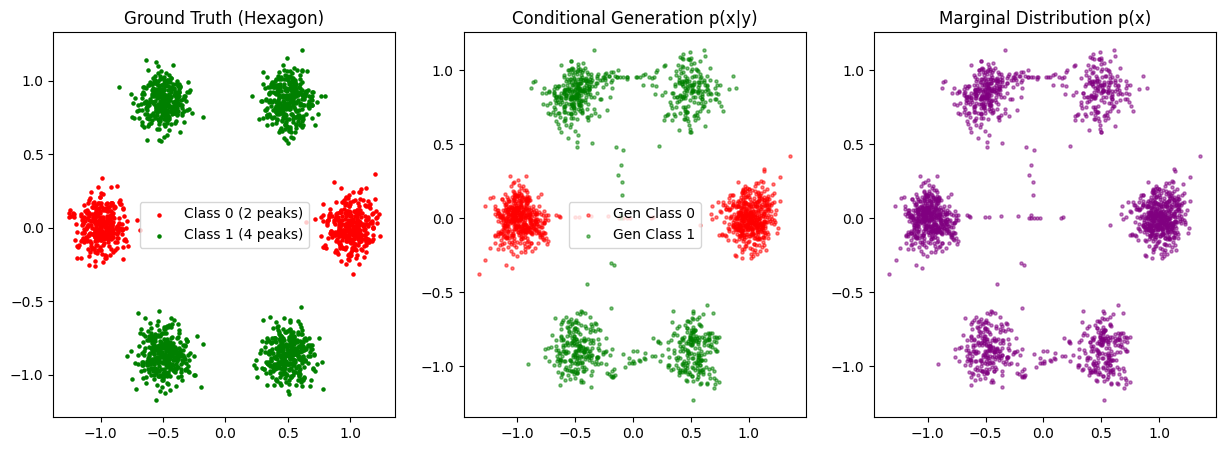

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# ==========================================
# 1. Model Architecture (Conditional RealNVP)
# ==========================================

class ConditionalCouplingLayer(nn.Module):
    def __init__(self, input_size, hidden_size, mask, condition_size):
        """
        Extended Coupling Layer for Conditional INN.
        nested_net input = input_size + condition_size
        """
        super().__init__()
        self.register_buffer("mask", mask)
        
        # The internal network now takes the data (masked) + the condition
        self.nested_net = nn.Sequential(
            nn.Linear(input_size + condition_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2 * input_size) # Output s and t
        )

    def forward(self, x, c):
        """
        x: Input data [batch, input_size]
        c: Condition  [batch, condition_size]
        """
        m = self.mask
        x_id = x * m
        
        # Concatenate the masked input with the condition
        # x is (Batch, 2), c is (Batch, 2) -> net_input is (Batch, 4)
        net_input = torch.cat((x_id, c), dim=1)
        
        h = self.nested_net(net_input)
        t, s = torch.chunk(h, 2, dim=-1)
        s = torch.tanh(s)
        scale = torch.exp(s)
        
        # Standard RealNVP coupling equation
        y = x_id + (1 - m) * (x * scale + t)
        logdet = ((1 - m) * s).sum(-1)
        
        return y, logdet

    def inverse(self, y, c):
        m = self.mask
        y_id = y * m
        
        # Concatenate here as well
        net_input = torch.cat((y_id, c), dim=1)
        
        h = self.nested_net(net_input)
        t, s = torch.chunk(h, 2, dim=-1)
        s = torch.tanh(s)
        scale = torch.exp(s)
        
        # Inverse equation
        x = y_id + (1 - m) * ((y - t) / scale)
        logdet = -((1 - m) * s).sum(dim=-1) # Inverse logdet is negative
        
        return x, logdet

def random_orthog(dim=2):
    """Generates random orthogonal matrix."""
    W = torch.randn(dim, dim)
    q, r = torch.linalg.qr(W)
    return q

class ConditionalRealNVP(nn.Module):
    def __init__(self, input_size=2, hidden_size=32, blocks=4, condition_size=2):
        super().__init__()
        self.blocks = blocks
        
        # Create masks (alternating [1,0] and [0,1])
        masks = []
        for i in range(blocks):
            mask = torch.tensor([1., 0.]) if i % 2 == 0 else torch.tensor([0., 1.])
            masks.append(mask)
            
        self.couplings = nn.ModuleList([
            ConditionalCouplingLayer(input_size, hidden_size, m, condition_size) 
            for m in masks
        ])
        
        # Random rotations between blocks
        self.rotations = nn.ModuleList()
        for _ in range(blocks - 1):
            R = nn.Linear(input_size, input_size, bias=False)
            with torch.no_grad():
                R.weight.copy_(random_orthog(input_size))
            for p in R.parameters():
                p.requires_grad = False
            self.rotations.append(R)
            
        # Final rotation (Identity)
        R = nn.Linear(input_size, input_size, bias=False)
        with torch.no_grad():
            R.weight.copy_(torch.eye(input_size))
            R.weight.requires_grad_(False)
        self.rotations.append(R)

    def forward(self, x, c):
        logdet_total = torch.zeros(x.size(0), device=x.device)
        y = x
        
        for i in range(self.blocks):
            y, logdet = self.couplings[i](y, c) # Pass condition
            logdet_total += logdet
            y = self.rotations[i](y)
            
        return y, logdet_total

    def inverse(self, y, c):
        # Inverse pass
        x = y
        logdet_total = torch.zeros(y.size(0), device=y.device)
        
        for i in reversed(range(self.blocks)):
            R = self.rotations[i].weight
            x = torch.matmul(x, R.t()) # Inverse rotation
            
            x, logdet = self.couplings[i].inverse(x, c) # Pass condition
            logdet_total += logdet
            
        return x, logdet_total

    def sample(self, num_samples, conditions):
        """
        Generate num_samples for EVERY row in conditions.
        conditions: [n_labels, condition_size]
        """
        device = next(self.parameters()).device
        conditions = conditions.to(device)
        n_labels = conditions.size(0)
        
        # Repeat conditions: 
        # If conditions is [[1,0], [0,1]] (Label 0, Label 1)
        # We want [Label0...Label0 (100 times), Label1...Label1 (100 times)]
        c_expanded = conditions.repeat_interleave(num_samples, dim=0)
        
        # Sample Latent z
        total_samples = n_labels * num_samples
        z = torch.randn(total_samples, 2, device=device)
        
        # Decode
        x_gen, _ = self.inverse(z, c_expanded)
        
        return x_gen

# ==========================================
# 2. Helper Functions (Loss, Data)
# ==========================================

def nll_loss(z, log_det):
    # Negative Log Likelihood
    D = z.size(1)
    # log p(z) = -0.5 * ||z||^2 - D/2 * log(2pi)
    log_pz = -0.5 * (z ** 2).sum(dim=1) - 0.5 * D * np.log(2 * np.pi)
    log_px = log_pz + log_det
    return -log_px.mean()

def get_one_hot(labels, num_classes=2):
    return torch.nn.functional.one_hot(torch.tensor(labels).long(), num_classes).float()

# ==========================================
# 3. Data Generation
# ==========================================

def get_moons_data(n_samples=2000, noise=0.1):
    X, y = make_moons(n_samples=n_samples, noise=noise)
    X = torch.tensor(X, dtype=torch.float32)
    # Convert y (0/1) to One-Hot
    y_onehot = get_one_hot(y, 2)
    return X, y_onehot, y

def get_hexagon_data(n_samples=2000, sigma=0.1, R=1.0):
    centers = []
    for k in range(6):
        theta = 2 * np.pi * k / 6
        centers.append((R * np.cos(theta), R * np.sin(theta)))
    centers = np.array(centers)
    
    # Assign components
    comp_indices = np.random.randint(0, 6, size=n_samples)
    means = centers[comp_indices]
    X = means + sigma * np.random.randn(n_samples, 2)
    
    # Create Labels for Task 2
    # Label 0: 2 specific peaks (e.g., index 0 and 3)
    # Label 1: The other 4 peaks
    labels = np.zeros(n_samples)
    
    # Let's say indices 0 and 3 are Class 0 (Red)
    # Indices 1, 2, 4, 5 are Class 1 (Green)
    mask_class_0 = (comp_indices == 0) | (comp_indices == 3)
    labels[mask_class_0] = 0
    labels[~mask_class_0] = 1
    
    X = torch.tensor(X, dtype=torch.float32)
    y_onehot = get_one_hot(labels, 2)
    
    return X, y_onehot, labels

# ==========================================
# 4. Training Function
# ==========================================

def train_conditional_inn(X, y_onehot, epochs=300, batch_size=128, lr=1e-3):
    dataset = TensorDataset(X, y_onehot)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    model = ConditionalRealNVP(input_size=2, hidden_size=64, blocks=6, condition_size=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    print("Starting training...")
    for ep in range(epochs):
        model.train()
        batch_loss = []
        for bx, by in loader:
            z, log_det = model(bx, by) # Pass data AND condition
            loss = nll_loss(z, log_det)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_loss.append(loss.item())
            
        if (ep + 1) % 50 == 0:
            print(f"Epoch {ep+1}/{epochs} | Loss: {np.mean(batch_loss):.4f}")
            
    return model

# ==========================================
# 5. Main Execution & Plots
# ==========================================

if __name__ == "__main__":
    # --- EXPERIMENT 1: TWO MOONS ---
    print("\n--- Running Two Moons Experiment ---")
    X_moon, y_moon_oh, y_moon_raw = get_moons_data(n_samples=2000)
    
    # Train
    model_moon = train_conditional_inn(X_moon, y_moon_oh, epochs=200, lr=5e-3)
    
    # Generate Conditional Samples
    # Create condition matrix: Row 0 -> Class 0, Row 1 -> Class 1
    conds = torch.tensor([[1., 0.], [0., 1.]]) 
    
    model_moon.eval()
    with torch.no_grad():
        # Generate 1000 samples for EACH condition (2000 total)
        x_gen = model_moon.sample(num_samples=1000, conditions=conds)
        x_gen = x_gen.cpu().numpy()
        
    # Split generated data back into classes for plotting
    # First 1000 are Class 0, next 1000 are Class 1
    x_gen_0 = x_gen[:1000]
    x_gen_1 = x_gen[1000:]
    
    # Plot
    plt.figure(figsize=(15, 5))
    
    # 1. Ground Truth
    plt.subplot(1, 3, 1)
    plt.scatter(X_moon[y_moon_raw==0][:,0], X_moon[y_moon_raw==0][:,1], s=5, c='red', label='Class 0')
    plt.scatter(X_moon[y_moon_raw==1][:,0], X_moon[y_moon_raw==1][:,1], s=5, c='blue', label='Class 1')
    plt.title("Ground Truth (Moons)")
    plt.legend()
    
    # 2. Conditional Generation (Separate)
    plt.subplot(1, 3, 2)
    plt.scatter(x_gen_0[:,0], x_gen_0[:,1], s=5, c='red', alpha=0.5, label='Gen Class 0')
    plt.scatter(x_gen_1[:,0], x_gen_1[:,1], s=5, c='blue', alpha=0.5, label='Gen Class 1')
    plt.title("Conditional Generation p(x|y)")
    plt.legend()
    
    # 3. Marginal Distribution (Merged)
    plt.subplot(1, 3, 3)
    plt.scatter(x_gen[:,0], x_gen[:,1], s=5, c='purple', alpha=0.5)
    plt.title("Marginal Distribution p(x)")
    plt.show()

    # --- EXPERIMENT 2: HEXAGON GMM ---
    print("\n--- Running Hexagon GMM Experiment ---")
    X_hex, y_hex_oh, y_hex_raw = get_hexagon_data(n_samples=2000)
    
    # Train
    model_hex = train_conditional_inn(X_hex, y_hex_oh, epochs=300, lr=1e-3)
    
    # Generate
    with torch.no_grad():
        x_gen_hex = model_hex.sample(num_samples=1000, conditions=conds)
        x_gen_hex = x_gen_hex.cpu().numpy()
        
    x_hex_0 = x_gen_hex[:1000]
    x_hex_1 = x_gen_hex[1000:]
    
    plt.figure(figsize=(15, 5))
    
    # 1. Ground Truth
    plt.subplot(1, 3, 1)
    plt.scatter(X_hex[y_hex_raw==0][:,0], X_hex[y_hex_raw==0][:,1], s=5, c='red', label='Class 0 (2 peaks)')
    plt.scatter(X_hex[y_hex_raw==1][:,0], X_hex[y_hex_raw==1][:,1], s=5, c='green', label='Class 1 (4 peaks)')
    plt.title("Ground Truth (Hexagon)")
    plt.legend()
    
    # 2. Conditional Generation
    plt.subplot(1, 3, 2)
    plt.scatter(x_hex_0[:,0], x_hex_0[:,1], s=5, c='red', alpha=0.5, label='Gen Class 0')
    plt.scatter(x_hex_1[:,0], x_hex_1[:,1], s=5, c='green', alpha=0.5, label='Gen Class 1')
    plt.title("Conditional Generation p(x|y)")
    plt.legend()
    
    # 3. Marginal
    plt.subplot(1, 3, 3)
    plt.scatter(x_gen_hex[:,0], x_gen_hex[:,1], s=5, c='purple', alpha=0.5)
    plt.title("Marginal Distribution p(x)")
    plt.show()